In [1]:
from two_D_project import Two_D_test, Particle_config
import numpy as np
from matplotlib import pyplot as plt

In [2]:
np.random.seed(13) # We set a seed for reproductibility
N = 1000
rho_target = 0.227
Length = np.sqrt(N / rho_target)  # Calculated from the reduced density

sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also
T_target = 0.1  # Target production temperature
cap = 800  # Max potential instead of infinity
max_step_size = 0.5  # Max step size for the MCMC

In [3]:
# Particle configuration is stored in a Particle_config object, which is then passed to the Two_D_test class for simulation.
pc = Particle_config(N=N, rho=rho_target, L=Length, sigma_0=sigma_0, sigma_1=sigma_1, epsilon=epsilon, T_target=T_target, cap=cap, max_step_size=max_step_size)
simulation = Two_D_test(pc)

Visualizing the initial particle configuration...


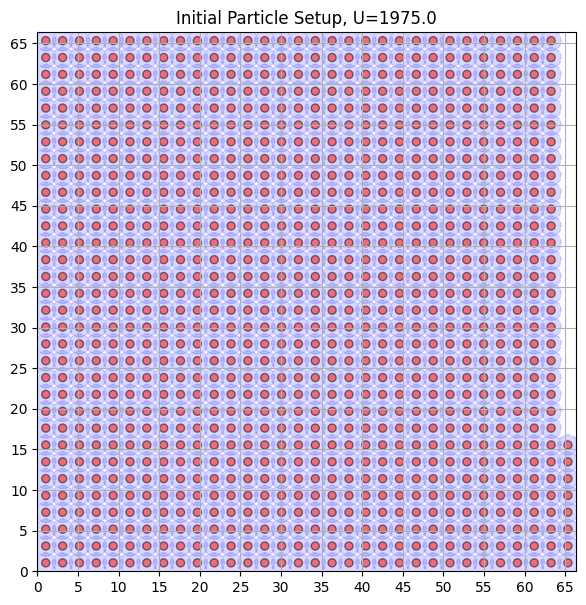

In [4]:
# Cold start on the orthogonal grid configuration
pc.cold_start_ort_grid_config()

# Or hot start
# pc.hot_start_config()

print("Visualizing the initial particle configuration...")
pc.visualize(title=f"Initial Particle Setup, U={pc.U_full()}")

Pre-equilibration:   0%|          | 0/300 [00:00<?, ?it/s]

Pre-equilibration:   5%|▍         | 14/300 [00:02<00:41,  6.88it/s]


Visualizing the particle configuration after pre-equilibration...


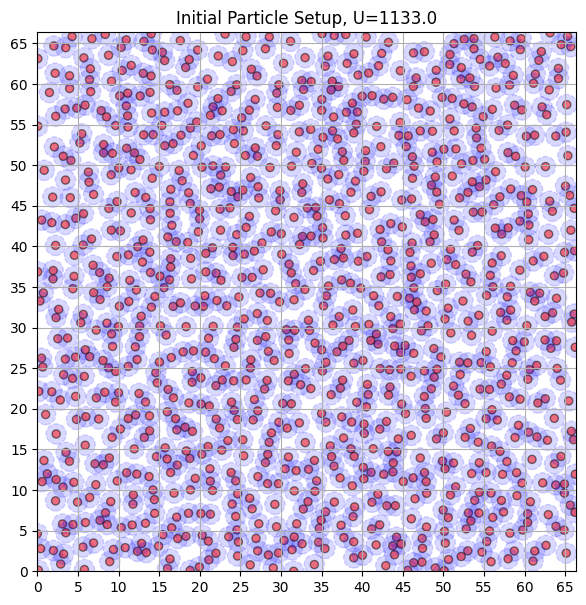

In [6]:
simulation.pre_equilibrate(T_high=T_target)

print("Visualizing the particle configuration after pre-equilibration...")
pc.visualize(title=f"Initial Particle Setup, U={pc.U_full()}")

Running Simulation: 100%|██████████| 500/500 [02:22<00:00,  3.52it/s]


acceptance_rate = 0.0231


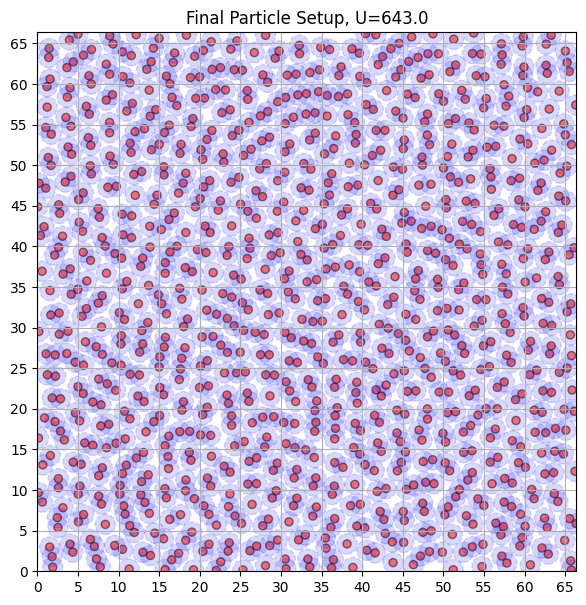

In [29]:
# n_iter=1000   - the number of iterations of MCMC,
# n_samples=100 - the number of samples evenly spaced in the iterations (the number of samples should be smaller than the number of iterations).,
# n_bins=300    - number of bins for the radial density histogram (the number of bins should be smaller than the number of samples).
# it is better to make n_iter a multiple of n_samples (actual n_iter = (n_iter // n_samples) * n_samples))
acceptance_rate = simulation.run_simulation(n_iter=1000000, n_samples=500, n_bins=300, draw=False)

print(f"acceptance_rate = {acceptance_rate:.4f}")
pc.visualize(title=f"Final Particle Setup, U={pc.U_full()}")

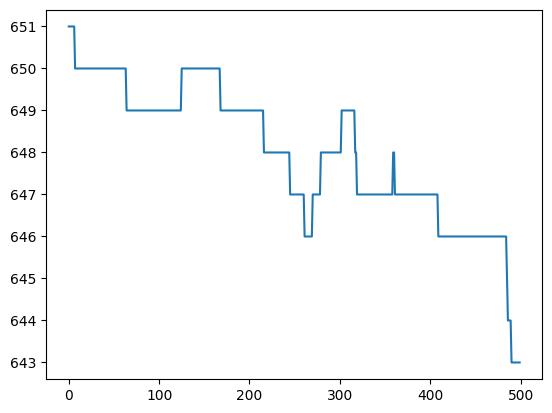

In [30]:
plt.plot(list(range(len(simulation.config.U_samples))), simulation.config.U_samples)


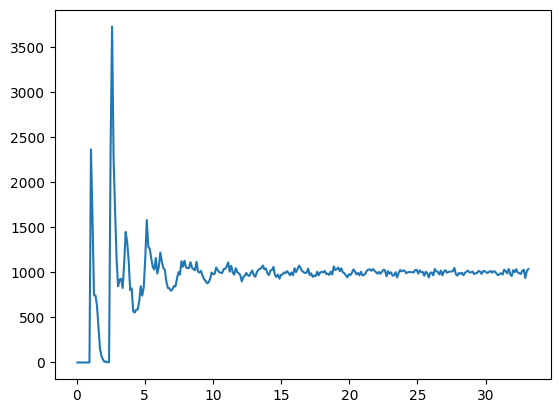

In [24]:
g, r = pc.average_radial_density(n_bins=300)
plt.plot(r,g) # Length / 2 = 33.18..

### Hexagonal grid test

In [7]:
pc1 = Particle_config(N=N+15, rho=rho_target, L=Length, sigma_0=sigma_0, sigma_1=sigma_1, epsilon=epsilon, T_target=T_target, cap=cap, max_step_size=max_step_size)
simulation = Two_D_test(pc1)

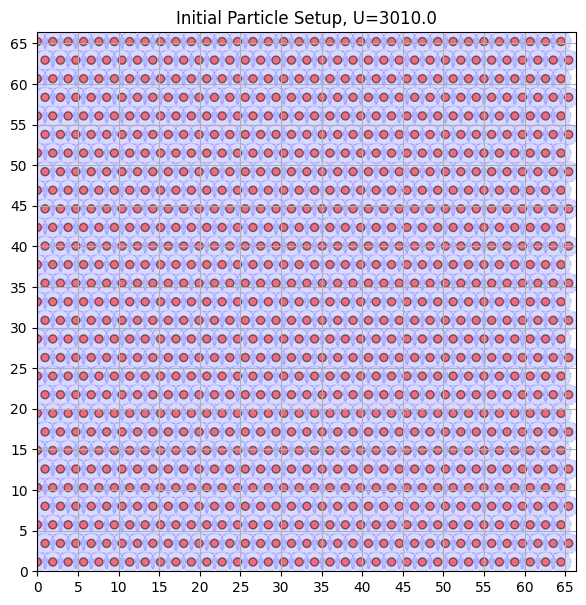

In [8]:
pc1.cold_start_hex_grid_config()
pc1.visualize(title=f"Initial Particle Setup, U={pc1.U_full()}")